In [1]:
import torch
import numpy as np
import torch.nn as nn
# import torch.nn.functional as F
import torch.nn.init as init
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os
import shutil
import imageio
import re
import datetime
import scipy

In [ ]:
顺序：1.构建一个随机连接的RNN网络。采用LIF模型。延迟常数按照随机分布5ms（80%）和100ms。连接情况为幂律分布，兴奋性和抑制性为80%。步长是1ms。
     2.输入DMS信号，类型为4种，结果为2类。一次DMS任务的两个信号是连续的。然后结束输入后来得到输出。下一次任务的输入要在静息状态后。通过训练controlsignal来控制神经网络的输出。
     
日志：将延迟扩展到750ms后可以训练成功
     增加维纳过程
     增加输出图像。接下来要做的事情是：1.加入限制项2.绘制control signal

SyntaxError: invalid character '：' (U+FF1A) (3299196997.py, line 1)

In [2]:
#生成数据集
params = {'delay':150,'taus':[5,100],'T':900}
#任务输入和相对应的标签
def generate_data_dms(num_samples=4,dt = 1 , T=900 ,start=50, dur=50,delay=150):
    for item in [T/dt, start/dt, (start+dur+delay)/dt, (start+2*dur+delay)/dt]:
        if item%1 != 0:
            print('错误，所设时间点和时间步长不能整除')
            print   ('T/dt = {}, start/dt = {}, (start+dur+delay)/dt = {}, (start+2*dur+delay)/dt = {}'.format(T/dt, start/dt, (start+dur+delay)/dt, (start+2*dur+delay)/dt))
            return
    #dt为时间步长，T为输入刺激的总时间,start为que信号开始输入刺激的时间，dur为刺激的持续时间，delay为两个信号之间的延迟（前一个末尾到后一个的开头），时间单位为s
    #创建输入信号：que和sample signal 还有 label信号，都放在一个tensor里
    datas = torch.zeros([3,int(T/dt)])
    start_que = int(start/dt) #que开始时的时间步
    end_que = int((start+dur)/dt) #que结束时的时间步
    start_sample = int((start+dur+delay)/dt) #sample开始时的时间步
    end_sample = int((start+2*dur+delay)/dt) #sample结束时的时间步
    datas[0,start_que:end_que] = 1 #que signal
    datas[1,start_sample:end_sample] = 1 #sample signal
    datas[2,int(end_sample):] = 1 #label data
    #输入信号对应的符号
    signs = np.random.choice([-1, 1], size = (num_samples, 2))
    #标签
    labels = (-1)**((signs[:, 0] != signs[:, 1]).astype(int))
  

    return datas, torch.FloatTensor(signs), torch.Tensor(labels)

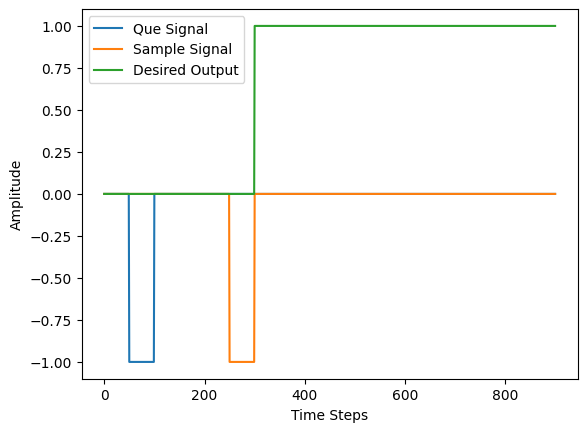

In [3]:
# 简单看一下生成的数据
sample_datas, sample_signs, sample_labels= generate_data_dms(delay = params['delay'], T=params['T'])
steps = range(len(sample_datas[0]))
plt.plot(steps, sample_datas[0]*sample_signs[0,0],label='Que Signal')
plt.plot(steps, sample_datas[1]*sample_signs[0,1],label='Sample Signal')
plt.plot(steps, sample_datas[2]*sample_labels[0],label='Desired Output')
plt.xlabel('Time Steps')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

In [4]:
#定义RNN
class ContinuousRNN(nn.Module):
    def __init__(self, N = 100 , P_inh = 0.2 , P_rec=0.2 , delay=150, taus=[5, 100], dt=1 , apply_dale=True, w_dist = 'gaus'):
        
        super().__init__()
        self.N = N
        self.P_inh = P_inh
        self.delay = delay
        self.taus = taus
        self.dt = dt
        self.apply_dale = apply_dale
        self.DeltaT = torch.tensor(1,dtype=torch.float32)
        self.P_rec = P_rec
        self.w_dist = w_dist



         #定义兴奋性和抑制性神经元
        self.inh, self.exc, self.NI, self.NE = self.assign_exc_inh()

         #初始化连接矩阵
        # self.W, self.mask = nn.Parameter(self.initialize_W())
        self.full_w,self.spectral_radius = self.initialize_W()

        self.taus = torch.tensor(np.random.choice([5, 100], size=(100, 1), p=[0.8, 0.2]), dtype=torch.float32)


         #输入矩阵和输出矩阵
        self.w_in = torch.randn(N,2)
        # self.w_out = torch.tensor(w_out,dtype=torch.float32)
        self.w_out = nn.Linear(N,1)
        init.normal_(self.w_out.weight, mean = 0, std = 0.01)

        self.control_signal = nn.Parameter(torch.randn(100, 900)) 


    def assign_exc_inh(self):
        """
        Method to randomly assign units as excitatory or inhibitory (Dale's principle)
        Returns
            inh: bool array marking which units are inhibitory
            exc: bool array marking which units are excitatory
            NI: number of inhibitory units
            NE: number of excitatory units
        """
        inh = torch.rand(self.N) < self.P_inh
        exc = ~inh
        NI = inh.sum().item()
        NE = self.N - NI

        return inh, exc, NI, NE
    
    def initialize_W(self):
        w = torch.zeros(self.N, self.N)
        idx = torch.nonzero(torch.rand(self.N, self.N) < self.P_rec).t() #得到有连接的位置索引（2x连接数）
        if self.w_dist.lower() == 'gamma':
            w[idx[0],idx[1]] = torch.tensor(torch.distributions.gamma.Gamma(2,0.003).sample((len(idx[0]),)),dtype=torch.float32)
        elif self.w_dist.lower() == 'gaus':
            w[idx[0],idx[1]] = torch.randn(len(idx[0]))
            w = w / torch.sqrt(torch.tensor(self.N*self.P_rec, dtype=torch.float32)) # scale by a gain to make it chaotic
        # 计算特征值
        w = torch.abs(w)

        #Mask Matrix, store exc and inh index
        mask = torch.eye(self.N)
        mask[torch.where(self.inh==True)[0],torch.where(self.inh==True)[0]] = -1

        full_w = torch.mm(w, mask)


        eigenvalues = np.linalg.eigvals(full_w)

        spectral_radius = np.max(np.abs(eigenvalues))

        # full_w = full_w / spectral_radius * 0.85 # scale to have spectral radius < 1

        spectral_radius = np.max(np.abs(np.linalg.eigvals(full_w))) #重新计算谱半径，确保小于1

       

        return full_w, spectral_radius

    def to(self, device):
        super().to(device)
        #将有必要的属性转为tensor并移动到指定的device
        self.w_in = self.w_in.to(device)
        self.w_out = self.w_out.to(device)
        self.full_w = self.full_w.to(device)
        self.taus = self.taus.to(device)
        self.DeltaT = self.DeltaT.to(device)
        self.N = torch.tensor(self.N).to(device)
        self.control_signal = self.control_signal.to(device)
        return self


    def forward(self, x, h=None):
        DeltaT = self.DeltaT
        # N = torch.tensor(self.N).to(x.device)
        # x shape: (batch_size, seq_len, input_size)
        batch_size, seq_len, input_size = x.size()

        #初始化h0,即synaptic current
        if h is None:
            # h = (torch.randn([batch_size,self.N])/100).to(x.device) #初始值取自均值为零，标准差为0.01的正态分布
            h = (torch.randn([self.N,batch_size])/100).to(x.device) #初始值取自均值为零，标准差为0.01的正态分布 size(N,batch_size)

        fr = torch.sigmoid(h)        # Firing rate size (N,batch_size)

        hs = torch.zeros([self.N,seq_len,batch_size]).to(x.device)# hs size (N,seq_len,batch_size)
        frs = torch.zeros([self.N,seq_len,batch_size]).to(x.device)# Firing rates size (N,seq_len,batch_size)
        output = torch.zeros([batch_size,seq_len]).to(x.device) # Output size (batch_size, seq_len)
       
        hs[:,0] = h
        frs[:,0] = fr

        #确保W是非负的,这块地方应该检查一下有没有问题，比如梯度有没有继承之类的
        # self.W = nn.Parameter(torch.relu(self.W))

        # For each time step in the input sequence
        for t in range(1,seq_len):
            # self.W = nn.Parameter(torch.relu(self.W))

            

            #Pass the synaptic decay time constants through the sigmoid function
            
            # taus_sig = taus_sig.unsqueeze(1)
            #前向传播方程
            # h = (1-DeltaT/taus_sig)*h+DeltaT/taus_sig*torch.mm(full_w,fr)+torch.mm(self.w_in,x[:,t-1,:].t())+torch.randn(self.N,batch_size,device = x.device)/10
            h = (1-DeltaT/self.taus)*h+DeltaT/self.taus*(torch.mm(self.full_w,fr)+torch.mm(self.w_in,x[:,t-1,:].t()))+self.dt * self.control_signal[:,t-1].unsqueeze(1)+0.1*torch.randn(self.N,batch_size,device = x.device)
            # hs[:,t] = h.squeeze()
            hs[:,t] = h
            fr = torch.sigmoid(h)
            # frs[:,t] = fr.squeeze()
            frs[:,t] = fr
            o = self.w_out(fr.squeeze().t())    
            output[:,t] = o.squeeze()# output shape: (batch_size, seq_len)
            output_ultra = output[:,601:701]
        return output,output_ultra,hs,frs




       

Using device: cuda:0
trial: 0
loss:  1.9906404113769531
Accuracy:  0.5399999618530273
trial: 100
loss:  1.9522767639160157
Accuracy:  0.5199999809265137
trial: 200
loss:  1.9145429992675782
Accuracy:  0.3999999761581421
trial: 300
loss:  1.8765916442871093
Accuracy:  0.8299999833106995
trial: 400
loss:  1.839973907470703
Accuracy:  0.5199999809265137
trial: 500
loss:  1.8039492797851562
Accuracy:  0.4399999976158142
trial: 600
loss:  1.7681196594238282
Accuracy:  0.5199999809265137
trial: 700
loss:  1.7333583068847656
Accuracy:  0.6800000071525574
trial: 800
loss:  1.698970184326172
Accuracy:  0.6699999570846558
trial: 900
loss:  1.665047607421875
Accuracy:  0.5600000023841858
trial: 1000
loss:  1.6318782043457032
Accuracy:  0.8199999928474426
trial: 1100
loss:  1.5993081665039062
Accuracy:  0.8100000023841858
trial: 1200
loss:  1.5673480224609375
Accuracy:  0.8199999928474426
trial: 1300
loss:  1.5361392211914062
Accuracy:  0.6599999666213989
trial: 1400
loss:  1.5054396057128907
Accu

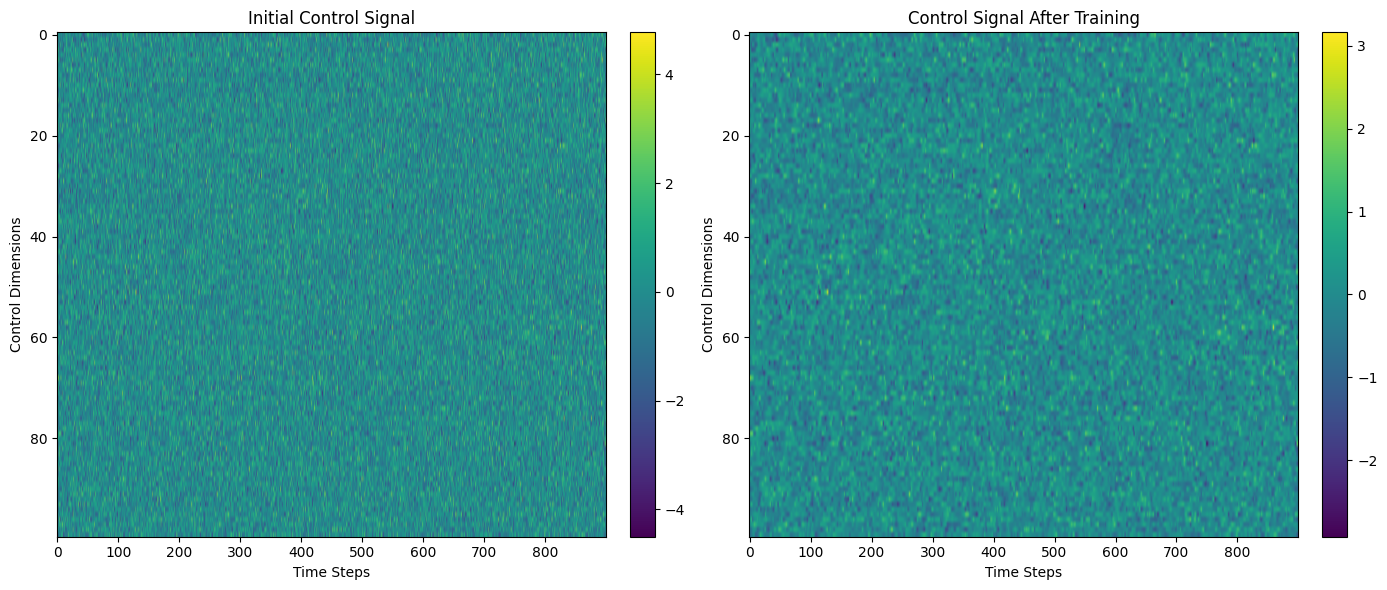

In [5]:
# 训练 RNN 直到收敛（恢复原来的训练 cell） 训练一次
train_success = False
fail_count = 0  # 记录失败次数

while not train_success:
    # 初始化
    model = ContinuousRNN(taus=params['taus'])
    initial_control_signal = model.control_signal.detach().cpu().clone()

    # Loss and optimizer（你可以在这里改正则系数）
    loss_fn = nn.MSELoss(reduction='sum')  # 这里创建了对象（实际训练用 criterion）

    def criterion(y_pred, y_true, model):
        task_loss = torch.sqrt(torch.mean((y_pred - y_true) ** 2))

        u = model.control_signal  # (N, T)

        # 时间平滑
        du_time = u[:, 1:] - u[:, :-1]
        smooth_time = torch.mean(du_time ** 2)

        # 空间平滑（相邻神经元）
        du_space = u[1:, :] - u[:-1, :]
        smooth_space = torch.mean(du_space ** 2)

        lambda_time = 100
        lambda_space = 0
    

        return task_loss + lambda_time * smooth_time + lambda_space * smooth_space

    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

    # 选择 device：有 CUDA 就用 GPU，否则用 CPU（避免 no cuda gpus are available）
    device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
    print('Using device:', device)
    model = model.to(device)

    # 开始训练
    num_epochs = 100

    train_losses_all = []
    val_losses_all = []
    train_accuracies_all = []
    avg_train_accuracies = []

    # 记录读出向量/偏置（沿用你原来的写法）
    W_out_record = model.w_out.weight.detach()
    b_out_record = model.w_out.bias.detach()

    for epoch in range(num_epochs):
        batch_size = 100

        # 训练集
        train_datas, train_signs, train_labels = generate_data_dms(
            num_samples=10000,
            delay=params['delay'],
            T=900,
        )
        train_input = train_datas[0:2, :]
        train_label = train_datas[2, :]

        # 验证集
        valid_datas, valid_signs, valid_labels = generate_data_dms(
            num_samples=100,
            delay=params['delay'],
            T=900,
        )
        valid_input = valid_datas[0:2, :]
        valid_label = valid_datas[2, :]

        train_losses = []

        for i in range(0, len(train_signs), batch_size):
            # 构造输入
            train_input_expanded = train_input.t().unsqueeze(0)
            train_signs_expanded = train_signs[i:i + batch_size, :].unsqueeze(1)
            inputs = train_input_expanded * train_signs_expanded

            labels = torch.mm(
                train_labels[i:i + batch_size].unsqueeze(1),
                train_label.unsqueeze(0)
            )
            labels = labels[:, 601:701]

            inputs, labels = inputs.to(device), labels.to(device)

            output, outputs_ultra, hs, frs = model(1000 * inputs.float())
            loss = criterion(outputs_ultra, labels.float(), model)

            train_losses.append(loss.item() / batch_size)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # 记录参数
            W_out_record = torch.cat((W_out_record, model.w_out.weight.detach()), dim=1)
            b_out_record = torch.cat((b_out_record, model.w_out.bias.detach()), dim=0)

            if i % 1 == 0:
                print('trial:', i)
                print('loss: ', loss.item() / batch_size)

                outputs_mean = torch.mean(outputs_ultra, dim=1, keepdim=True)
                accuracy = torch.mean((torch.sign(outputs_mean) == torch.sign(labels)).float())
                print('Accuracy: ', accuracy.item())

                train_accuracies_all.append(accuracy.item())
                avg_train_accuracies.append(sum(train_accuracies_all) / len(train_accuracies_all))

        train_losses_all.extend(train_losses)

        # 每个 epoch 做一次验证
        print(f'Training Epoch [{epoch + 1}/{num_epochs}], Loss: {sum(train_losses) / len(train_losses):.4f}')

        batch_size_val = 10
        print(f'Start Validation[{epoch + 1}/{num_epochs}]...')

        val_losses = []
        val_acc = []

        model.eval()
        with torch.no_grad():
            for i in range(0, len(valid_signs), batch_size_val):
                valid_input_expanded = valid_input.t().unsqueeze(0)
                valid_signs_expanded = valid_signs[i:i + batch_size_val, :].unsqueeze(1)
                inputs = valid_input_expanded * valid_signs_expanded

                labels_data = torch.mm(
                    valid_labels[i:i + batch_size_val].unsqueeze(1),
                    valid_label.unsqueeze(0)
                )
                labels_data = labels_data[:, 601:701]

                inputs = inputs.to(device)
                labels_data = labels_data.to(device)
                labels = valid_labels[i:i + batch_size_val].to(device)

                output, outputs_, hs, frs = model(1000 * inputs.float())
                loss = criterion(outputs_, labels_data.float(), model)

                val_losses.append(loss.item() / batch_size_val)
                eval_start = torch.where(labels_data[0, :] != 0)[0][0].to(device)
                max_vals, _ = torch.max(torch.abs(outputs_[:, eval_start:]), dim=1)
                acc = (torch.sign(torch.mean(outputs_[:, eval_start:], dim=1)) == torch.sign(labels)) & (max_vals > 0.7)
                val_acc.extend(acc.tolist())

        val_acc = [int(v) for v in val_acc]
        mean_val_loss = sum(val_losses) / len(val_losses)
        mean_val_acc = sum(val_acc) / len(val_acc)

        print(f'Validation[{epoch + 1}/{num_epochs}] Loss: {mean_val_loss}, Accuracy: {mean_val_acc}')
        val_losses_all.extend(val_losses)

        if mean_val_loss < 100 and mean_val_acc > 0.95:
            train_success = True
            print('Training Finished')
            print('Trails:', len(train_losses_all))
            print('Failed Count:', fail_count)
            break

        if epoch == num_epochs - 1:
            train_success = False
            fail_count += 1
            print('Training Failed')
            print('Trails:', len(train_losses_all))
            print('Failed Count:', fail_count)

    # 训练完成后拿到 final_control_signal，供后面可视化
    final_control_signal = model.control_signal.detach().cpu()

    # 初始/训练后 control_signal 热图对比
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    im0 = axes[0].imshow(initial_control_signal.numpy(), aspect='auto', cmap='viridis')
    axes[0].set_title('Initial Control Signal')
    axes[0].set_xlabel('Time Steps')
    axes[0].set_ylabel('Control Dimensions')
    fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    im1 = axes[1].imshow(final_control_signal.numpy(), aspect='auto', cmap='viridis')
    axes[1].set_title('Control Signal After Training')
    axes[1].set_xlabel('Time Steps')
    axes[1].set_ylabel('Control Dimensions')
    fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()



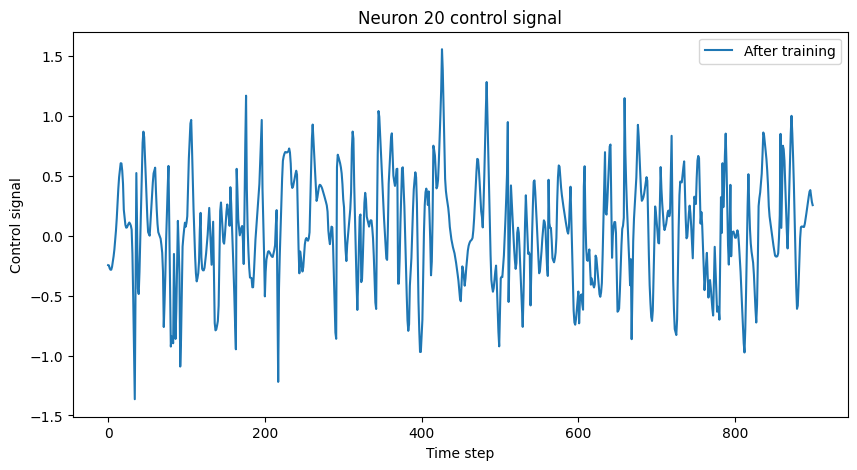

In [6]:
  # （从中间 cell 挪出来的）单个神经元 control signal 可视化
# 依赖：先运行训练 cell，得到 initial_control_signal / final_control_signal

n = 20

u_init = initial_control_signal[n].numpy()   # 训练前
u_final = final_control_signal[n].numpy()    # 训练后

plt.figure(figsize=(10, 5))
# plt.plot(u_init, '--', label='Before training')
plt.plot(u_final, label='After training')
plt.legend()
plt.xlabel('Time step')
plt.ylabel('Control signal')
plt.title(f'Neuron {n} control signal')
plt.show()


In [ ]:
# ============== 2D Grid Sweep: lambda_time × lambda_space（各训练 1 次，100 组合）==============
# 这一格是“直接可运行”的：不依赖你先跑很慢的 sweep cell。
# 只依赖你已经运行过前面那些很快的定义：ContinuousRNN / generate_data_dms / params（以及 torch 已安装）。
# 输出：每次运行创建 ResultX/cs1、cs2、cs3...，CSV 和 control_signal 矩阵保存至该次文件夹
# 计算和画图在后续 cell 中单独完成
# 共享网络：每个点训练前重置 control_signal 和 w_out，其他网络参数（full_w, w_in, taus 等）保持不变

import time
import csv
from pathlib import Path
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import torch
import torch.nn as nn


# --------- 依赖检查（缺了就直接报清楚） ---------
missing = []
for name in ["ContinuousRNN", "generate_data_dms", "params"]:
    if name not in globals():
        missing.append(name)
if missing:
    raise RuntimeError(
        "这个 cell 需要你先运行前面定义这些对象的 cell: " + ", ".join(missing)
    )


def train_once(lambda_time: float,
               lambda_space: float,
               timeout_seconds: float = 600.0,
               num_epochs: int = 100,
               batch_size_train: int = 100,
               batch_size_valid: int = 10,
               train_samples: int = 10000,
               valid_samples: int = 100,
               lr: float = 0.01,
               seed=None,
               verbose: bool = False):
    """单次训练：返回 success/timeout/耗时等。

    成功判据沿用你原来的：
    - mean(val_loss) < 100
    - mean(val_acc) > 0.95
    """

    if seed is not None:
        # numpy 的 seed 需要在 [0, 2**32 - 1] 范围内
        seed = int(seed) % (2**32 - 1)
        np.random.seed(seed)
        torch.manual_seed(seed)

    model = ContinuousRNN(taus=params['taus'])

    device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    def criterion(y_pred, y_true, model):
        task_loss = torch.sqrt(torch.mean((y_pred - y_true) ** 2))

        u = model.control_signal

        # 时间平滑
        du_time = u[:, 1:] - u[:, :-1]
        smooth_time = torch.mean(du_time ** 2)

        # 空间平滑（相邻神经元）
        du_space = u[1:, :] - u[:-1, :]
        smooth_space = torch.mean(du_space ** 2)

        return task_loss + float(lambda_time) * smooth_time + float(lambda_space) * smooth_space

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    start_t = time.time()
    timeout = False
    train_success = False

    train_losses_all = []
    val_losses_all = []
    val_acc_all = []

    # 验证集（每次 train_once 固定一份，用于更稳定对比）
    valid_datas, valid_signs, valid_labels = generate_data_dms(
        num_samples=valid_samples,
        delay=params['delay'],
        T=900,
    )
    valid_input = valid_datas[0:2, :]
    valid_label = valid_datas[2, :]

    validate_every_samples = 1000  # 你要求：每 1000 个样本做一次验证（batch=100 即每 10 个 batch）

    def run_validation():
        model.eval()
        val_losses = []
        val_acc = []

        with torch.no_grad():
            for i in range(0, len(valid_signs), batch_size_valid):
                if time.time() - start_t > timeout_seconds:
                    return None, None, True

                valid_input_expanded = valid_input.t().unsqueeze(0)
                valid_signs_expanded = valid_signs[i:i + batch_size_valid, :].unsqueeze(1)
                inputs = valid_input_expanded * valid_signs_expanded

                labels_data = torch.mm(
                    valid_labels[i:i + batch_size_valid].unsqueeze(1),
                    valid_label.unsqueeze(0)
                )
                labels_data = labels_data[:, 601:701]

                inputs = inputs.to(device)
                labels_data = labels_data.to(device)
                labels = valid_labels[i:i + batch_size_valid].to(device)

                output, outputs_, hs, frs = model(1000 * inputs.float())
                loss = criterion(outputs_, labels_data.float(), model)
                val_losses.append(loss.item() / max(1, inputs.shape[0]))

                eval_start = torch.where(labels_data[0, :] != 0)[0][0].to(device)
                max_vals, _ = torch.max(torch.abs(outputs_[:, eval_start:]), dim=1)
                acc = (torch.sign(torch.mean(outputs_[:, eval_start:], dim=1)) == torch.sign(labels)) & (max_vals > 0.7)
                val_acc.extend(acc.tolist())

        val_acc_int = [int(v) for v in val_acc]
        mean_val_loss = float(sum(val_losses) / max(1, len(val_losses)))
        mean_val_acc = float(sum(val_acc_int) / max(1, len(val_acc_int)))
        val_losses_all.extend(val_losses)
        val_acc_all.append(mean_val_acc)
        return mean_val_loss, mean_val_acc, False

    for epoch in range(num_epochs):
        if time.time() - start_t > timeout_seconds:
            timeout = True
            break

        # 训练集（每个 epoch 生成一份 10000 样本）
        train_datas, train_signs, train_labels = generate_data_dms(
            num_samples=train_samples,
            delay=params['delay'],
            T=900,
        )
        train_input = train_datas[0:2, :]
        train_label = train_datas[2, :]

        model.train()
        epoch_losses = []
        seen_samples = 0

        for i in range(0, len(train_signs), batch_size_train):
            if time.time() - start_t > timeout_seconds:
                timeout = True
                break

            train_input_expanded = train_input.t().unsqueeze(0)
            train_signs_expanded = train_signs[i:i + batch_size_train, :].unsqueeze(1)
            inputs = train_input_expanded * train_signs_expanded

            labels = torch.mm(
                train_labels[i:i + batch_size_train].unsqueeze(1),
                train_label.unsqueeze(0)
            )
            labels = labels[:, 601:701]

            inputs, labels = inputs.to(device), labels.to(device)

            output, outputs_ultra, hs, frs = model(1000 * inputs.float())
            loss = criterion(outputs_ultra, labels.float(), model)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_losses.append(loss.item() / max(1, inputs.shape[0]))
            seen_samples += int(inputs.shape[0])

            if verbose and (i % (batch_size_train * 5) == 0):
                print(f"epoch={epoch} i={i} loss={epoch_losses[-1]:.6f}")

            # 每训练 1000 个样本做一次验证
            if seen_samples % validate_every_samples == 0:
                mean_val_loss, mean_val_acc, val_timeout = run_validation()
                if val_timeout:
                    timeout = True
                    break
                if (mean_val_loss is not None) and (mean_val_loss < 100) and (mean_val_acc > 0.95):
                    train_success = True
                    break

        if timeout:
            break

        train_losses_all.extend(epoch_losses)

        if train_success:
            break

    elapsed = time.time() - start_t

    # --- 指标：time-variance / neuron-wise variance（来自最终的 control_signal） ---
    # control_signal 形状 (N, T) = (100, 900)，dim0=神经元，dim1=时间
    # time-variance：对每个神经元在时间维度的方差，再对神经元求平均
    # neuron-wise variance：对每个时间点在神经元维度的方差，再对时间求平均
    time_variance = None
    neuron_wise_variance = None
    try:
        u = model.control_signal.detach().cpu()
        if u.ndim == 2:
            with torch.no_grad():
                time_variance = float(u.var(dim=1, unbiased=False).mean().item())
                neuron_wise_variance = float(u.var(dim=0, unbiased=False).mean().item())
    except Exception:
        pass

    return {
        "lambda_time": float(lambda_time),
        "lambda_space": float(lambda_space),
        "success": bool(train_success),
        "timeout": bool(timeout and (not train_success)),
        "elapsed_seconds": float(elapsed),
        "epochs_ran": int(epoch + 1) if 'epoch' in locals() else 0,
        "device": str(device),
        "last_val_acc": float(val_acc_all[-1]) if len(val_acc_all) else None,
        "time_variance": time_variance,
        "neuron_wise_variance": neuron_wise_variance,
        "train_losses_len": int(len(train_losses_all)),
        "val_losses_len": int(len(val_losses_all)),
    }

# 正式训练：每个参数组合只训练 1 次，但始终使用同一个神经网络（不重新初始化）
# 注意：这会让后续组合是在“前面组合训练后的模型状态”上继续训练，结果具有路径依赖性。

# 只跑 (k1=100, k2=0) 这一个点
# 10×10 = 100 个参数组合
k1_vals = [0.0, 0.01, 0.1, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0, 100.0, 1000.0, 10000.0, 100000.0]
k2_vals = [0.0, 0.01, 0.1, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0, 100.0, 1000.0, 10000.0, 100000.0]
points = [(k1, k2) for k1 in k1_vals for k2 in k2_vals]

lambda_time_values = sorted({float(lt) for lt, _ in points})
lambda_space_values = sorted({float(ls) for _, ls in points})

timeout_seconds = 10 * 60

out_dir = Path("/SanDisk/xiang/ResultX")
run_tag = datetime.now().strftime("%Y%m%d_%H%M%S")
# 每次运行创建 cs1、cs2、cs3... 递增文件夹
existing_cs = [p for p in out_dir.iterdir() if p.is_dir() and p.name.startswith("cs")]
nums = []
for p in existing_cs:
    suffix = p.name[2:]
    if suffix.isdigit():
        nums.append(int(suffix))
next_num = max(nums) + 1 if nums else 1
run_folder = out_dir / f"cs{next_num}"
run_folder.mkdir(parents=True, exist_ok=True)
out_csv = run_folder / f"lambda_time_space_grid_sharednet_{run_tag}.csv"

fieldnames = [
    "lambda_time",
    "lambda_space",
    "success",
    "timeout",
    "elapsed_seconds",
    "epochs_ran",
    "device",
    "last_val_acc",
    "train_losses_len",
    "val_losses_len",
    "seed",
]

print("Grid sweep start (shared network; 1 run per point)")
print("  points:", len(points))
print("  timeout_seconds:", timeout_seconds)
print("  run_folder:", str(run_folder))
print("  saving to:", str(out_csv))

# 写表头
with open(out_csv, "w", newline="", encoding="utf-8") as f:
    csv.DictWriter(f, fieldnames=fieldnames).writeheader()

# -------- 初始化一次模型/优化器/验证集（整个 sweep 共用） --------
# 每次运行使用不同 seed，使两次训练得到不同结果（由 run_tag 时间戳决定）
base_seed = int(run_tag.replace("_", "")) % (2**32 - 1)
print("  base_seed:", base_seed)
np.random.seed(base_seed)
torch.manual_seed(base_seed)

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = ContinuousRNN(taus=params['taus']).to(device)

# shared-net：每个参数组合都训练 control_signal + w_out，但每次都会把它们重置回同一起点
# 其它网络结构/连接（如 full_w 等）保持不变

# 只让这两类参数参与训练
for name, p in model.named_parameters():
    p.requires_grad_(name in {'control_signal', 'w_out.weight', 'w_out.bias'})

optimizer = torch.optim.Adam([model.control_signal, *model.w_out.parameters()], lr=0.01)

# 保存初始值：每个参数组合开始前重置
control_signal_init = model.control_signal.detach().clone()
w_out_w_init = model.w_out.weight.detach().clone()
w_out_b_init = model.w_out.bias.detach().clone()


def reset_control_and_wout():
    # 必须都是 Parameter，否则训练会不可靠
    if not isinstance(model.control_signal, torch.nn.Parameter):
        raise RuntimeError(f"control_signal 不是 nn.Parameter，而是 {type(model.control_signal)}")
    if not isinstance(model.w_out.weight, torch.nn.Parameter):
        raise RuntimeError(f"w_out.weight 不是 nn.Parameter，而是 {type(model.w_out.weight)}")
    if not isinstance(model.w_out.bias, torch.nn.Parameter):
        raise RuntimeError(f"w_out.bias 不是 nn.Parameter，而是 {type(model.w_out.bias)}")

    with torch.no_grad():
        model.control_signal.copy_(control_signal_init)
        model.w_out.weight.copy_(w_out_w_init)
        model.w_out.bias.copy_(w_out_b_init)

    # 清梯度 + 清 Adam 状态（确保每个点从同一起点开始）
    model.control_signal.grad = None
    model.w_out.weight.grad = None
    model.w_out.bias.grad = None
    optimizer.state.clear()


# 固定一份验证集（整个 sweep 共用，避免波动）
valid_datas, valid_signs, valid_labels = generate_data_dms(
    num_samples=100,
    delay=params['delay'],
    T=900,
)
valid_input = valid_datas[0:2, :]
valid_label = valid_datas[2, :]

batch_size_train = 100
batch_size_valid = 10
train_samples = 10000
num_epochs = 100
validate_every_samples = 1000


def run_validation(lambda_time, lambda_space, start_t):
    def criterion(y_pred, y_true):
        task_loss = torch.sqrt(torch.mean((y_pred - y_true) ** 2))
        u = model.control_signal
        du_time = u[:, 1:] - u[:, :-1]
        smooth_time = torch.mean(du_time ** 2)
        du_space = u[1:, :] - u[:-1, :]
        smooth_space = torch.mean(du_space ** 2)
        return task_loss + float(lambda_time) * smooth_time + float(lambda_space) * smooth_space

    model.eval()
    val_losses = []
    val_acc = []

    with torch.no_grad():
        for i in range(0, len(valid_signs), batch_size_valid):
            if time.time() - start_t > timeout_seconds:
                return None, None, True

            vin = valid_input.t().unsqueeze(0)
            vs = valid_signs[i:i + batch_size_valid, :].unsqueeze(1)
            inputs = vin * vs

            labels_data = torch.mm(
                valid_labels[i:i + batch_size_valid].unsqueeze(1),
                valid_label.unsqueeze(0)
            )
            labels_data = labels_data[:, 601:701]

            inputs = inputs.to(device)
            labels_data = labels_data.to(device)
            labels = valid_labels[i:i + batch_size_valid].to(device)

            _, outputs_, _, _ = model(1000 * inputs.float())
            loss = criterion(outputs_, labels_data.float())
            val_losses.append(loss.item() / max(1, inputs.shape[0]))

            eval_start = torch.where(labels_data[0, :] != 0)[0][0].to(device)
            max_vals, _ = torch.max(torch.abs(outputs_[:, eval_start:]), dim=1)
            acc = (torch.sign(torch.mean(outputs_[:, eval_start:], dim=1)) == torch.sign(labels)) & (max_vals > 0.7)
            val_acc.extend(acc.tolist())

    val_acc_int = [int(v) for v in val_acc]
    mean_val_loss = float(sum(val_losses) / max(1, len(val_losses)))
    mean_val_acc = float(sum(val_acc_int) / max(1, len(val_acc_int)))
    return mean_val_loss, mean_val_acc, False


def train_on_shared_model(lambda_time, lambda_space, seed):
    # 每个参数组合开始前：重置 control_signal + w_out（网络其它权重不重置）
    reset_control_and_wout()

    # seed 仅用于本次训练内生成数据（模型不重置）
    if seed is not None:
        seed = int(seed) % (2**32 - 1)
        np.random.seed(seed)
        torch.manual_seed(seed)

    # ========== 这是 loss function ==========
    def criterion(y_pred, y_true):
        task_loss = torch.sqrt(torch.mean((y_pred - y_true) ** 2))
        u = model.control_signal
        du_time = u[:, 1:] - u[:, :-1]
        smooth_time = torch.mean(du_time ** 2)
        du_space = u[1:, :] - u[:-1, :]
        smooth_space = torch.mean(du_space ** 2)
        return task_loss + float(lambda_time) * smooth_time + float(lambda_space) * smooth_space

    start_t = time.time()
    timeout = False
    success = False

    train_losses_len = 0
    val_losses_len = 0
    last_val_acc = None

    for epoch in range(num_epochs):
        if time.time() - start_t > timeout_seconds:
            timeout = True
            break

        train_datas, train_signs, train_labels = generate_data_dms(
            num_samples=train_samples,
            delay=params['delay'],
            T=900,
        )
        train_input = train_datas[0:2, :]
        train_label = train_datas[2, :]

        model.train()
        seen = 0

        for i in range(0, len(train_signs), batch_size_train):
            if time.time() - start_t > timeout_seconds:
                timeout = True
                break

            tin = train_input.t().unsqueeze(0)
            ts = train_signs[i:i + batch_size_train, :].unsqueeze(1)
            inputs = tin * ts

            labels = torch.mm(
                train_labels[i:i + batch_size_train].unsqueeze(1),
                train_label.unsqueeze(0)
            )
            labels = labels[:, 601:701]

            inputs, labels = inputs.to(device), labels.to(device)

            _, outputs_ultra, _, _ = model(1000 * inputs.float())
            loss = criterion(outputs_ultra, labels.float())

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_losses_len += 1
            seen += int(inputs.shape[0])

            if seen % validate_every_samples == 0:
                mean_val_loss, mean_val_acc, val_timeout = run_validation(lambda_time, lambda_space, start_t)
                if val_timeout:
                    timeout = True
                    break
                last_val_acc = mean_val_acc
                val_losses_len += int(np.ceil(len(valid_signs) / batch_size_valid))
                if (mean_val_loss is not None) and (mean_val_loss < 100) and (mean_val_acc > 0.95):
                    success = True
                    break

        if timeout or success:
            break

    elapsed = time.time() - start_t

    return {
        "success": bool(success),
        "timeout": bool(timeout and (not success)),
        "elapsed_seconds": float(elapsed),
        "epochs_ran": int(epoch + 1) if 'epoch' in locals() else 0,
        "device": str(device),
        "last_val_acc": last_val_acc,
        "train_losses_len": int(train_losses_len),
        "val_losses_len": int(val_losses_len),
    }

# -------- sweep：每个点训练 1 次（共享模型） --------
# 遍历 100 个参数组合（每个点训练前重置 control_signal 和 w_out，其他网络参数不变）

start_all = time.time()
run_idx = 0

def point_seed(lt, ls):
    seed_base = int(round(float(lt) * 1000)) * 100000 + int(round(float(ls) * 1000))
    return seed_base % (2**32 - 1)

for (lt, ls) in points:
    run_idx += 1
    seed = point_seed(lt, ls)
    print(f"Run {run_idx}/{len(points)}: lambda_time={lt:g}, lambda_space={ls:g}")

    res = train_on_shared_model(float(lt), float(ls), seed)

    # 保存 control_signal 矩阵 (100×900) 到 ResultX
    cs_path = run_folder / f"control_signal_lt{lt}_ls{ls}_{run_tag}.npy"
    np.save(cs_path, model.control_signal.detach().cpu().numpy())

    row = {
        "lambda_time": float(lt),
        "lambda_space": float(ls),
        "success": bool(res["success"]),
        "timeout": bool(res["timeout"]),
        "elapsed_seconds": float(res["elapsed_seconds"]),
        "epochs_ran": int(res["epochs_ran"]),
        "device": str(res["device"]),
        "last_val_acc": res["last_val_acc"],
        "train_losses_len": int(res["train_losses_len"]),
        "val_losses_len": int(res["val_losses_len"]),
        "seed": int(seed),
    }

    with open(out_csv, "a", newline="", encoding="utf-8") as f:
        csv.DictWriter(f, fieldnames=fieldnames).writerow(row)

    status = "SUCCESS" if row["success"] else ("TIMEOUT" if row["timeout"] else "FAIL")
    print(f"  -> {status}, elapsed={row['elapsed_seconds']:.1f}s")

print(f"Finished in {(time.time() - start_all)/60:.1f} minutes")
print("Saved:", str(out_csv))

# 给绘图 cell 用（让它自动画本次最新结果）
last_grid_csv_path = out_csvß


Grid sweep start (shared network; 1 run per point)
  points: 169
  timeout_seconds: 600
  run_folder: /SanDisk/xiang/ResultX/cs4
  saving to: /SanDisk/xiang/ResultX/cs4/lambda_time_space_grid_sharednet_20260313_155604.csv
  base_seed: 952425089
Run 1/169: lambda_time=0, lambda_space=0
  -> SUCCESS, elapsed=83.1s
Run 2/169: lambda_time=0, lambda_space=0.01
  -> SUCCESS, elapsed=71.1s
Run 3/169: lambda_time=0, lambda_space=0.1
  -> SUCCESS, elapsed=83.1s
Run 4/169: lambda_time=0, lambda_space=1
  -> SUCCESS, elapsed=83.1s
Run 5/169: lambda_time=0, lambda_space=2
  -> SUCCESS, elapsed=82.8s
Run 6/169: lambda_time=0, lambda_space=5
  -> SUCCESS, elapsed=95.3s
Run 7/169: lambda_time=0, lambda_space=10
  -> SUCCESS, elapsed=70.7s
Run 8/169: lambda_time=0, lambda_space=20
  -> SUCCESS, elapsed=95.3s
Run 9/169: lambda_time=0, lambda_space=50
  -> SUCCESS, elapsed=94.7s
Run 10/169: lambda_time=0, lambda_space=100
  -> SUCCESS, elapsed=95.2s
Run 11/169: lambda_time=0, lambda_space=1000
  -> SUCC

In [8]:
# 从 (100, 0) 训练的 control_signal 计算 time_variance
# time_variance: 每个神经元在时间维度的方差，再对神经元求平均
from pathlib import Path
import numpy as np

out_dir = Path("/SanDisk/xiang/ResultX")
candidates = sorted(out_dir.glob("controlsignal_*/control_signal_lt100*ls0*.npy"), key=lambda p: p.stat().st_mtime)
if not candidates:
    raise FileNotFoundError("找不到 control_signal 文件，请先运行训练 cell")
cs_path = candidates[-1]
u = np.load(cs_path)  # shape (100, 900): (N_neurons, T_time_steps)

time_variance = float(np.var(u, axis=1, ddof=0).mean())
print(f"time_variance = {time_variance}")

time_variance = 0.27853578329086304


In [ ]:
# ========== control signal2: k1=0 时各 k2 的 time_variance 和 neuron_wise_variance ==========
import numpy as np
import re
from pathlib import Path

data_folder = Path("/SanDisk/xiang/ResultX/controlsignal2")
# k1=0 对应的 k2 取值 (0 到 10000)
k2_list = [0.0, 0.01, 0.1, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0, 100.0, 1000.0, 10000.0]

# 建立 lt0.0 对应的文件映射
file_map = {}
for p in data_folder.glob("control_signal_lt0.0_*.npy"):
    m = re.search(r"ls([\d.]+)_", p.name)
    if m:
        k2 = float(m.group(1))
        file_map[k2] = p

rows = []
for k2 in k2_list:
    if k2 in file_map:
        u = np.load(file_map[k2])  # shape (N_neurons, T_time_steps)
        time_var = float(np.var(u, axis=1, ddof=0).mean())
        neuron_var = float(np.var(u, axis=0, ddof=0).mean())
        rows.append((k2, time_var, neuron_var))
    else:
        rows.append((k2, None, None))

# 表格输出
print("control signal2 数据 (k1=0, k2 从 0 到 10000)")
print("=" * 70)
print(f"{'k2 (lambda_space)':<22} {'time_variance':<20} {'neuron_wise_variance':<22}")
print("-" * 70)
for k2, tv, nv in rows:
    if tv is not None:
        print(f"{str(k2):<22} {tv:<20.6f} {nv:<22.6f}")
    else:
        print(f"{str(k2):<22} {'N/A':<20} {'N/A':<22}")
print("=" * 70)

control signal2 数据 (k1=0, k2 从 0 到 10000)
k2 (lambda_space)      time_variance        neuron_wise_variance  
----------------------------------------------------------------------
0.0                    1.002673             0.993967              
0.01                   0.495389             0.484450              
0.1                    0.391997             0.379866              
1.0                    0.274253             0.262031              
2.0                    0.322930             0.311572              
5.0                    0.299637             0.288068              
10.0                   0.335490             0.324354              
20.0                   0.296189             0.284618              
50.0                   0.295215             0.283586              
100.0                  0.279666             0.267800              
1000.0                 0.199129             0.185700              
10000.0                0.159772             0.145285              


In [13]:
# 从 (100, 0) 训练的 control_signal 计算 neuron_wise_variance
# neuron_wise_variance: 每个时间点在神经元维度的方差，再对时间求平均
from pathlib import Path
import numpy as np

out_dir = Path("/SanDisk/xiang/ResultX")
candidates = sorted(out_dir.glob("controlsignal_*/control_signal_lt100*ls0*.npy"), key=lambda p: p.stat().st_mtime)
if not candidates:
    raise FileNotFoundError("找不到 control_signal 文件，请先运行训练 cell")
u = np.load(candidates[-1])  # shape (100, 900)

neuron_wise_variance = float(np.var(u, axis=0, ddof=0).mean())
print(f"neuron_wise_variance = {neuron_wise_variance}")

neuron_wise_variance = 0.11888666450977325


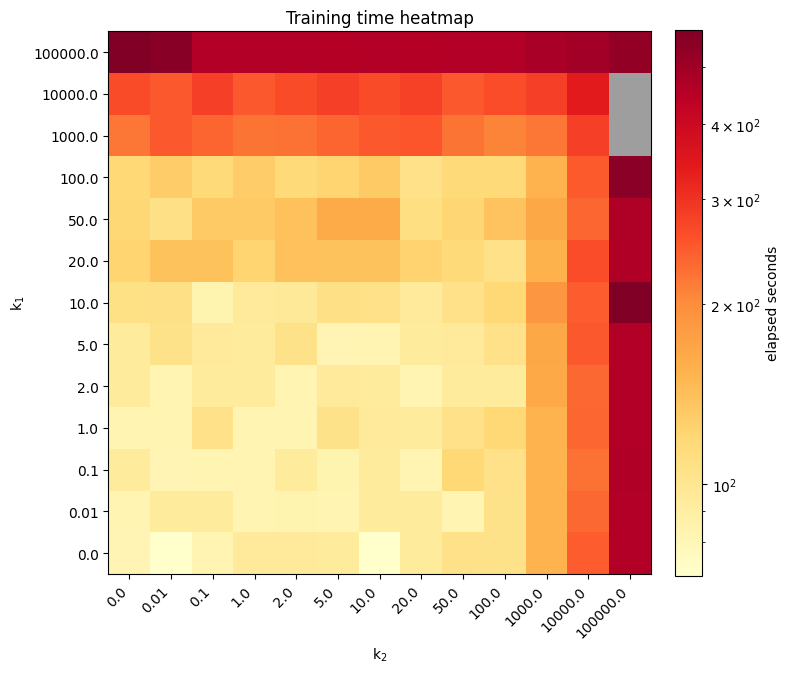

In [ ]:
# ========== 图1: 训练时间热力图（使用 cs1 数据）==========
# 修改 cs_run 可切换为 cs2、cs3... 对应不同训练 run
import csv
from pathlib import Path
from decimal import Decimal
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

out_dir = Path("/SanDisk/xiang/ResultX")
cs_run = "cs1"
data_folder = out_dir / cs_run
csv_candidates = sorted(data_folder.glob("lambda_time_space_grid_sharednet_*.csv"), key=lambda p: p.stat().st_mtime)
csv_path = csv_candidates[-1] if csv_candidates else (data_folder / "lambda_time_space_grid_sharednet.csv")

rows = []
with csv_path.open('r', encoding='utf-8', newline='') as f:
    for row in csv.DictReader(f):
        if row and not all((v is None or str(v).strip() == '') for v in row.values()):
            rows.append(row)

k1_set = set()
k2_set = set()
for row in rows:
    try:
        k1_set.add(Decimal(str(row['lambda_time']).strip()))
        k2_set.add(Decimal(str(row['lambda_space']).strip()))
    except Exception:
        pass
k1_values = sorted(k1_set)
k2_values = sorted(k2_set)
k1_to_i = {v: i for i, v in enumerate(k1_values)}
k2_to_j = {v: j for j, v in enumerate(k2_values)}
T, S = len(k1_values), len(k2_values)

out_pic_dir = out_dir / f"{cs_run}pic"
out_pic_dir.mkdir(parents=True, exist_ok=True)

def plot_heatmap(mat, title, cmap_name='YlOrRd', lognorm=False, vmin=None, vmax=None, cbar_label='', save_path=None):
    cmap = plt.get_cmap(cmap_name).copy()
    cmap.set_bad('#9e9e9e')
    data = np.ma.masked_invalid(mat)
    finite = np.asarray(mat)[np.isfinite(mat)]
    if vmin is None: vmin = float(np.nanmin(finite)) if finite.size else 0.0
    if vmax is None: vmax = float(np.nanmax(finite)) if finite.size else 1.0
    if lognorm:
        vmin = max(vmin, 1e-9)
        vmax = max(vmax, 1.0)  # 确保 colorbar 顶部显示 10^0
        norm = mcolors.LogNorm(vmin=vmin, vmax=vmax)
    else:
        norm = None
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_aspect('equal', adjustable='box')
    im = ax.imshow(data, origin='lower', cmap=cmap, norm=norm, vmin=None if norm else vmin, vmax=None if norm else vmax)
    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    if lognorm:
        from matplotlib.ticker import LogLocator
        cb.locator = LogLocator(subs=[1.0])
        cb.update_ticks()
    if cbar_label: cb.set_label(cbar_label)
    ax.set_xticks(range(S))
    ax.set_xticklabels([str(v) for v in k2_values], rotation=45, ha='right')
    ax.set_yticks(range(T))
    ax.set_yticklabels([str(v) for v in k1_values])
    ax.set_xlabel('k$_2$')
    ax.set_ylabel('k$_1$')
    ax.set_title(title)
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

time_mat = np.full((T, S), np.nan, dtype=float)
for row in rows:
    try:
        k1, k2 = Decimal(str(row['lambda_time']).strip()), Decimal(str(row['lambda_space']).strip())
        if str(row.get('success','')).lower() != 'true': continue
        i, j = k1_to_i[k1], k2_to_j[k2]
        time_mat[i, j] = float(row.get('elapsed_seconds'))
    except Exception: pass
plot_heatmap(time_mat, 'Training time heatmap', cmap_name='YlOrRd', lognorm=True, cbar_label='elapsed seconds', save_path=out_pic_dir / '1_training_time.png')



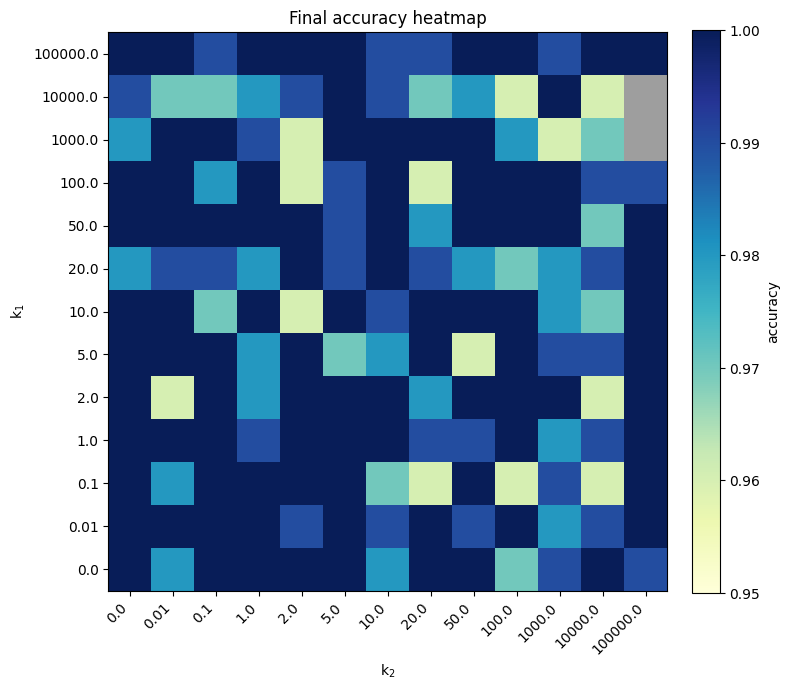

In [37]:
# ========== 图2: 准确率热力图（使用 cs1 数据）==========
import csv
from pathlib import Path
from decimal import Decimal
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

out_dir = Path("/SanDisk/xiang/ResultX")
cs_run = "cs1"
data_folder = out_dir / cs_run
csv_candidates = sorted(data_folder.glob("lambda_time_space_grid_sharednet_*.csv"), key=lambda p: p.stat().st_mtime)
csv_path = csv_candidates[-1] if csv_candidates else (data_folder / "lambda_time_space_grid_sharednet.csv")

rows = []
with csv_path.open('r', encoding='utf-8', newline='') as f:
    for row in csv.DictReader(f):
        if row and not all((v is None or str(v).strip() == '') for v in row.values()):
            rows.append(row)

k1_set = set()
k2_set = set()
for row in rows:
    try:
        k1_set.add(Decimal(str(row['lambda_time']).strip()))
        k2_set.add(Decimal(str(row['lambda_space']).strip()))
    except Exception:
        pass
k1_values = sorted(k1_set)
k2_values = sorted(k2_set)
k1_to_i = {v: i for i, v in enumerate(k1_values)}
k2_to_j = {v: j for j, v in enumerate(k2_values)}
T, S = len(k1_values), len(k2_values)

out_pic_dir = out_dir / f"{cs_run}pic"
out_pic_dir.mkdir(parents=True, exist_ok=True)

def plot_heatmap(mat, title, cmap_name='YlOrRd', lognorm=False, vmin=None, vmax=None, cbar_label='', save_path=None):
    cmap = plt.get_cmap(cmap_name).copy()
    cmap.set_bad('#9e9e9e')
    data = np.ma.masked_invalid(mat)
    finite = np.asarray(mat)[np.isfinite(mat)]
    if vmin is None: vmin = float(np.nanmin(finite)) if finite.size else 0.0
    if vmax is None: vmax = float(np.nanmax(finite)) if finite.size else 1.0
    if lognorm:
        vmin = max(vmin, 1e-9)
        vmax = max(vmax, 1.0)  # 确保 colorbar 顶部显示 10^0
        norm = mcolors.LogNorm(vmin=vmin, vmax=vmax)
    else:
        norm = None
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_aspect('equal', adjustable='box')
    im = ax.imshow(data, origin='lower', cmap=cmap, norm=norm, vmin=None if norm else vmin, vmax=None if norm else vmax)
    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    if lognorm:
        from matplotlib.ticker import LogLocator
        cb.locator = LogLocator(subs=[1.0])
        cb.update_ticks()
    if cbar_label: cb.set_label(cbar_label)
    ax.set_xticks(range(S))
    ax.set_xticklabels([str(v) for v in k2_values], rotation=45, ha='right')
    ax.set_yticks(range(T))
    ax.set_yticklabels([str(v) for v in k1_values])
    ax.set_xlabel('k$_2$')
    ax.set_ylabel('k$_1$')
    ax.set_title(title)
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

acc_mat = np.full((T, S), np.nan, dtype=float)
for row in rows:
    try:
        k1, k2 = Decimal(str(row['lambda_time']).strip()), Decimal(str(row['lambda_space']).strip())
        if str(row.get('success','')).lower() != 'true': continue
        i, j = k1_to_i[k1], k2_to_j[k2]
        acc = float(row.get('last_val_acc'))
        if np.isfinite(acc): acc_mat[i, j] = acc
    except Exception: pass
plot_heatmap(acc_mat, 'Final accuracy heatmap', cmap_name='YlGnBu', lognorm=False, vmin=0.95, vmax=1.0, cbar_label='accuracy', save_path=out_pic_dir / '2_accuracy.png')



/tmp/ipykernel_1223123/64120715.py:27: UserWarning: Glyph 28909 (\N{CJK UNIFIED IDEOGRAPH-70ED}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1223123/64120715.py:27: UserWarning: Glyph 21147 (\N{CJK UNIFIED IDEOGRAPH-529B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1223123/64120715.py:27: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1223123/64120715.py:27: UserWarning: Glyph 27719 (\N{CJK UNIFIED IDEOGRAPH-6C47}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1223123/64120715.py:27: UserWarning: Glyph 24635 (\N{CJK UNIFIED IDEOGRAPH-603B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1223123/64120715.py:28: UserWarning: Glyph 28909 (\N{CJK UNIFIED IDEOGRAPH-70ED}) missing from font(s) DejaVu Sans.
  plt.savefig(out_pic_dir / '0_combined_4heatmaps.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_1223123/

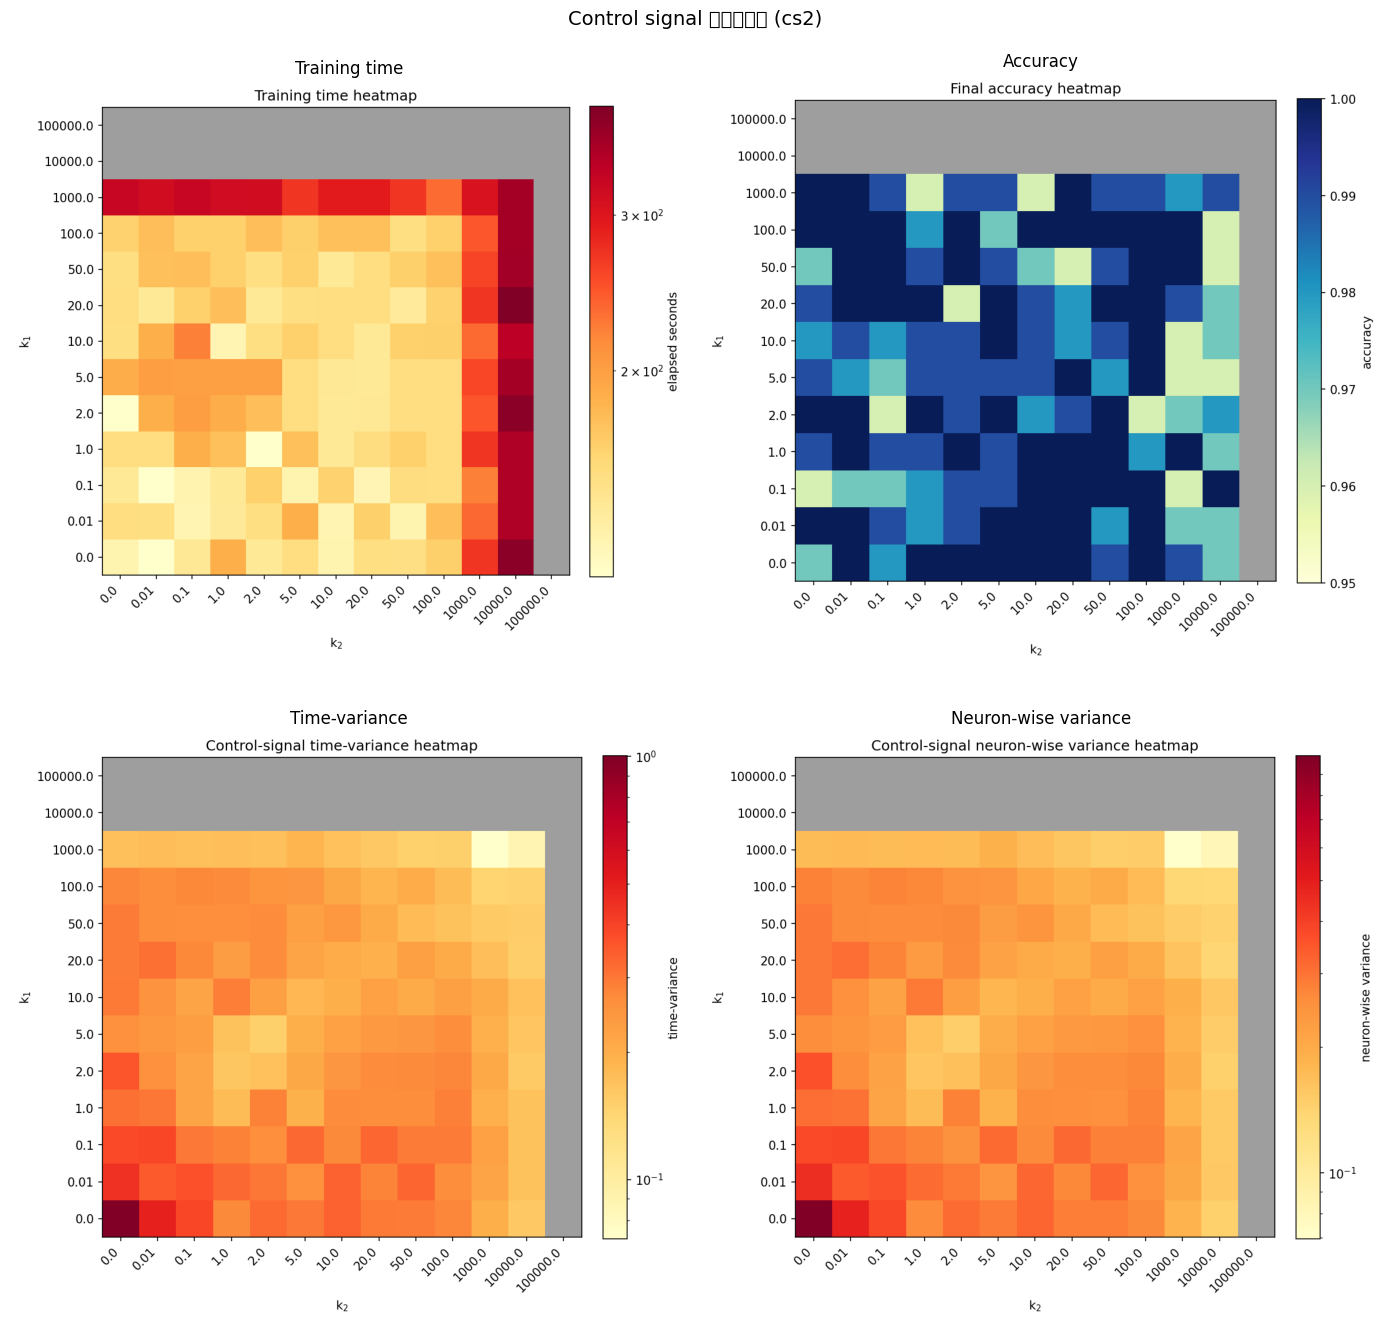

In [ ]:
# ========== 四图合并：2×2 总体图 ==========
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

out_dir = Path("/SanDisk/xiang/ResultX")
cs_run = "cs2"  # 与前面四个图一致，可改为 cs2、cs3...
out_pic_dir = out_dir / f"{cs_run}pic"

fig, axes = plt.subplots(2, 2, figsize=(14, 14))
imgs = [
    ('1_training_time.png', 'Training time'),
    ('2_accuracy.png', 'Accuracy'),
    ('3_time_variance.png', 'Time-variance'),
    ('4_neuron_wise_variance.png', 'Neuron-wise variance'),
]
for ax, (fname, title) in zip(axes.flat, imgs):
    path = out_pic_dir / fname
    if path.exists():
        img = mpimg.imread(path)
        ax.imshow(img)
        ax.set_title(title, fontsize=12)
    else:
        ax.text(0.5, 0.5, f'未找到\n{fname}', ha='center', va='center')
    ax.axis('off')
plt.suptitle(f'Control signal 热力图汇总 ({cs_run})', fontsize=14)
plt.tight_layout()
plt.savefig(out_pic_dir / '0_combined_4heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()

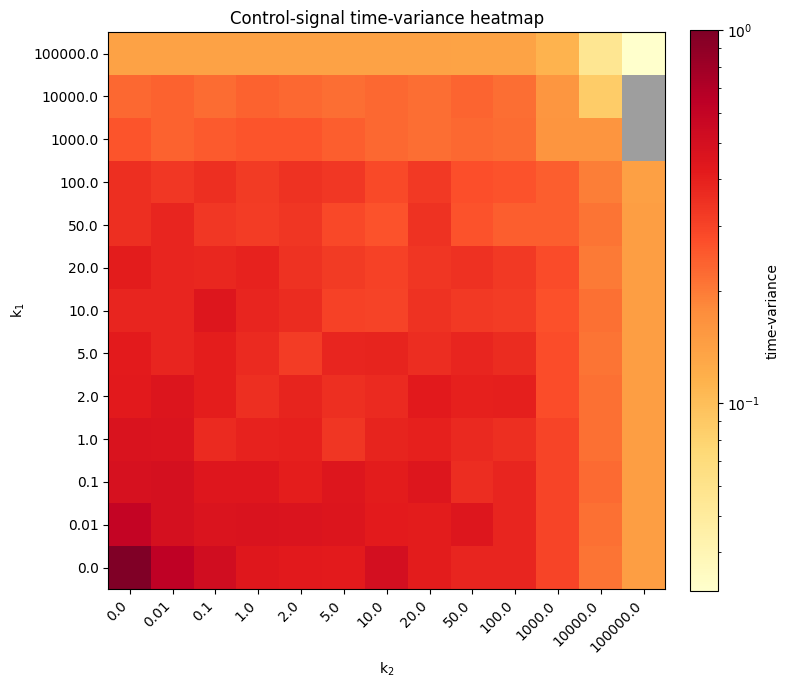

In [ ]:
# ========== 图3: Control-signal time-variance 热力图（从 cs1 的 .npy 计算）==========
import csv
import re
from pathlib import Path
from decimal import Decimal
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

out_dir = Path("/SanDisk/xiang/ResultX")
cs_run = "cs1"
data_folder = out_dir / cs_run
csv_candidates = sorted(data_folder.glob("lambda_time_space_grid_sharednet_*.csv"), key=lambda p: p.stat().st_mtime)
csv_path = csv_candidates[-1] if csv_candidates else (data_folder / "lambda_time_space_grid_sharednet.csv")

rows = []
with csv_path.open('r', encoding='utf-8', newline='') as f:
    for row in csv.DictReader(f):
        if row and not all((v is None or str(v).strip() == '') for v in row.values()):
            rows.append(row)

k1_set = set()
k2_set = set()
for row in rows:
    try:
        k1_set.add(Decimal(str(row['lambda_time']).strip()))
        k2_set.add(Decimal(str(row['lambda_space']).strip()))
    except Exception:
        pass
k1_values = sorted(k1_set)
k2_values = sorted(k2_set)
k1_to_i = {v: i for i, v in enumerate(k1_values)}
k2_to_j = {v: j for j, v in enumerate(k2_values)}
T, S = len(k1_values), len(k2_values)

# 解析 cs1 中所有 .npy 文件名，建立 (lt, ls) -> 文件路径 的映射
file_map = {}
for p in data_folder.glob("control_signal_*.npy"):
    m = re.match(r"control_signal_lt([\d.]+)_ls([\d.]+)_\d+_\d+\.npy", p.name)
    if m:
        lt, ls = float(m.group(1)), float(m.group(2))
        file_map[(lt, ls)] = p

out_pic_dir = out_dir / f"{cs_run}pic"
out_pic_dir.mkdir(parents=True, exist_ok=True)

def plot_heatmap(mat, title, cmap_name='YlOrRd', lognorm=False, vmin=None, vmax=None, cbar_label='', save_path=None):
    cmap = plt.get_cmap(cmap_name).copy()
    cmap.set_bad('#9e9e9e')
    data = np.ma.masked_invalid(mat)
    finite = np.asarray(mat)[np.isfinite(mat)]
    if vmin is None: vmin = float(np.nanmin(finite)) if finite.size else 0.0
    if vmax is None: vmax = float(np.nanmax(finite)) if finite.size else 1.0
    if lognorm:
        vmin = max(vmin, 1e-9)
        vmax = max(vmax, 1.0)  # 确保 colorbar 顶部显示 10^0
        norm = mcolors.LogNorm(vmin=vmin, vmax=vmax)
    else:
        norm = None
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_aspect('equal', adjustable='box')
    im = ax.imshow(data, origin='lower', cmap=cmap, norm=norm, vmin=None if norm else vmin, vmax=None if norm else vmax)
    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    if lognorm:
        from matplotlib.ticker import LogLocator
        cb.locator = LogLocator(subs=[1.0])
        cb.update_ticks()
    if cbar_label: cb.set_label(cbar_label)
    ax.set_xticks(range(S))
    ax.set_xticklabels([str(v) for v in k2_values], rotation=45, ha='right')
    ax.set_yticks(range(T))
    ax.set_yticklabels([str(v) for v in k1_values])
    ax.set_xlabel('k$_2$')
    ax.set_ylabel('k$_1$')
    ax.set_title(title)
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

timevar_mat = np.full((T, S), np.nan, dtype=float)
for row in rows:
    try:
        k1, k2 = Decimal(str(row['lambda_time']).strip()), Decimal(str(row['lambda_space']).strip())
        if str(row.get('success','')).lower() != 'true': continue
        i, j = k1_to_i[k1], k2_to_j[k2]
        key = (float(k1), float(k2))
        if key in file_map:
            u = np.load(file_map[key])
            timevar_mat[i, j] = float(np.var(u, axis=1, ddof=0).mean())
    except Exception: pass
plot_heatmap(timevar_mat, 'Control-signal time-variance heatmap', cmap_name='YlOrRd', lognorm=True, cbar_label='time-variance', save_path=out_pic_dir / '3_time_variance.png')



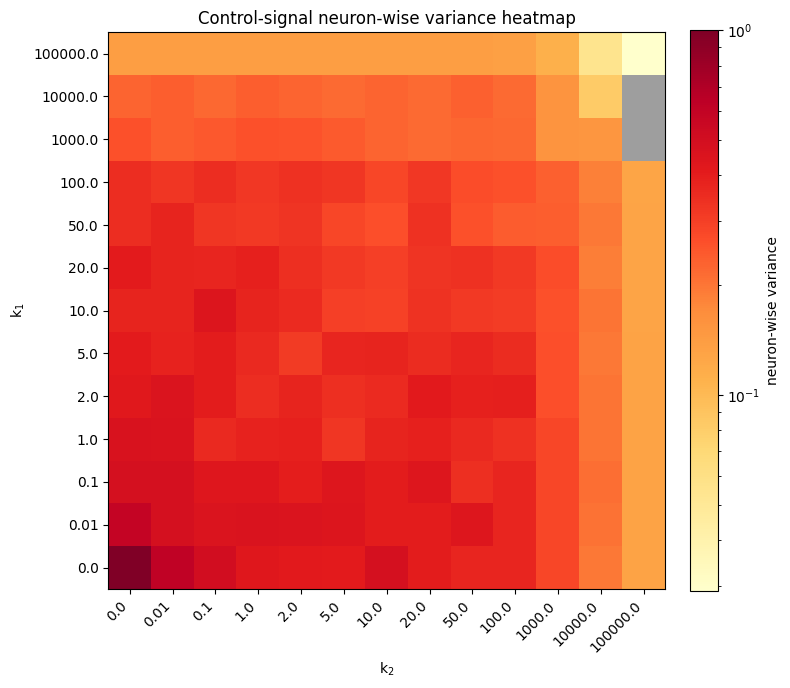

In [ ]:
# ========== 图4: Control-signal neuron-wise variance 热力图（从 cs1 的 .npy 计算）==========
import csv
import re
from pathlib import Path
from decimal import Decimal
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

out_dir = Path("/SanDisk/xiang/ResultX")
cs_run = "cs1"
data_folder = out_dir / cs_run
csv_candidates = sorted(data_folder.glob("lambda_time_space_grid_sharednet_*.csv"), key=lambda p: p.stat().st_mtime)
csv_path = csv_candidates[-1] if csv_candidates else (data_folder / "lambda_time_space_grid_sharednet.csv")

rows = []
with csv_path.open('r', encoding='utf-8', newline='') as f:
    for row in csv.DictReader(f):
        if row and not all((v is None or str(v).strip() == '') for v in row.values()):
            rows.append(row)

k1_set = set()
k2_set = set()
for row in rows:
    try:
        k1_set.add(Decimal(str(row['lambda_time']).strip()))
        k2_set.add(Decimal(str(row['lambda_space']).strip()))
    except Exception:
        pass
k1_values = sorted(k1_set)
k2_values = sorted(k2_set)
k1_to_i = {v: i for i, v in enumerate(k1_values)}
k2_to_j = {v: j for j, v in enumerate(k2_values)}
T, S = len(k1_values), len(k2_values)

# 解析 cs1 中所有 .npy 文件名，建立 (lt, ls) -> 文件路径 的映射
file_map = {}
for p in data_folder.glob("control_signal_*.npy"):
    m = re.match(r"control_signal_lt([\d.]+)_ls([\d.]+)_\d+_\d+\.npy", p.name)
    if m:
        lt, ls = float(m.group(1)), float(m.group(2))
        file_map[(lt, ls)] = p

out_pic_dir = out_dir / f"{cs_run}pic"
out_pic_dir.mkdir(parents=True, exist_ok=True)

def plot_heatmap(mat, title, cmap_name='YlOrRd', lognorm=False, vmin=None, vmax=None, cbar_label='', save_path=None):
    cmap = plt.get_cmap(cmap_name).copy()
    cmap.set_bad('#9e9e9e')
    data = np.ma.masked_invalid(mat)
    finite = np.asarray(mat)[np.isfinite(mat)]
    if vmin is None: vmin = float(np.nanmin(finite)) if finite.size else 0.0
    if vmax is None: vmax = float(np.nanmax(finite)) if finite.size else 1.0
    if lognorm:
        vmin = max(vmin, 1e-9)
        vmax = max(vmax, 1.0)  # 确保 colorbar 顶部显示 10^0
        norm = mcolors.LogNorm(vmin=vmin, vmax=vmax)
    else:
        norm = None
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_aspect('equal', adjustable='box')
    im = ax.imshow(data, origin='lower', cmap=cmap, norm=norm, vmin=None if norm else vmin, vmax=None if norm else vmax)
    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    if lognorm:
        from matplotlib.ticker import LogLocator
        cb.locator = LogLocator(subs=[1.0])
        cb.update_ticks()
    if cbar_label: cb.set_label(cbar_label)
    ax.set_xticks(range(S))
    ax.set_xticklabels([str(v) for v in k2_values], rotation=45, ha='right')
    ax.set_yticks(range(T))
    ax.set_yticklabels([str(v) for v in k1_values])
    ax.set_xlabel('k$_2$')
    ax.set_ylabel('k$_1$')
    ax.set_title(title)
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

neuronvar_mat = np.full((T, S), np.nan, dtype=float)
for row in rows:
    try:
        k1, k2 = Decimal(str(row['lambda_time']).strip()), Decimal(str(row['lambda_space']).strip())
        if str(row.get('success','')).lower() != 'true': continue
        i, j = k1_to_i[k1], k2_to_j[k2]
        key = (float(k1), float(k2))
        if key in file_map:
            u = np.load(file_map[key])
            neuronvar_mat[i, j] = float(np.var(u, axis=0, ddof=0).mean())
    except Exception: pass
plot_heatmap(neuronvar_mat, 'Control-signal neuron-wise variance heatmap', cmap_name='YlOrRd', lognorm=True, cbar_label='neuron-wise variance', save_path=out_pic_dir / '4_neuron_wise_variance.png')
